## Imports

In [1]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Create models directory
os.makedirs('models', exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.4.2
Pandas version: 3.0.1


In [2]:
# ==================== Helper Functions: Evaluation Metrics ====================

def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def calc_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def calc_mbe(y_true, y_pred):
    return np.mean(y_pred - y_true)

def calc_p95(y_true, y_pred):
    return np.percentile(np.abs(y_true - y_pred), 95)

def evaluate_model(y_true, y_pred, horizons=7, include_bias=False):
    """Evaluate per horizon + macro average.
    Args:
        y_true: (n_samples, 7) array of true values
        y_pred: (n_samples, 7) array of predictions
        horizons: number of horizons
        include_bias: if True, also compute MBE and P95
    """
    results = []
    for k in range(horizons):
        row = {
            'Horizon': f't+{k+1}',
            'RMSE': calc_rmse(y_true[:, k], y_pred[:, k]),
            'MAE': calc_mae(y_true[:, k], y_pred[:, k]),
        }
        if include_bias:
            row['MBE'] = calc_mbe(y_true[:, k], y_pred[:, k])
            row['P95'] = calc_p95(y_true[:, k], y_pred[:, k])
        results.append(row)

    # Macro average
    macro = {'Horizon': 'Macro-Avg'}
    for metric in ['RMSE', 'MAE'] + (['MBE', 'P95'] if include_bias else []):
        macro[metric] = np.mean([r[metric] for r in results])
    results.append(macro)

    return pd.DataFrame(results)

print("Helper functions defined.")

Helper functions defined.


## Part A: Data Preprocessing

### A.1 Load and Clean Data

Load all 18 CSV files (1996–2013) and remove rows where `bad_quality = 1`.

In [3]:
# Load all CSV files
all_dfs = []
for year in range(1996, 2014):
    filepath = f'datasets/daily_solar_{year}.csv'
    df_year = pd.read_csv(filepath)
    all_dfs.append(df_year)

df_raw = pd.concat(all_dfs, ignore_index=True)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f"Total rows loaded: {len(df_raw)}")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
print(f"\nBad quality statistics:")
print(f"  Total bad_quality=1: {df_raw['bad_quality'].sum()}")
print(f"  Percentage bad: {df_raw['bad_quality'].mean()*100:.2f}%")
print(f"  Total bad_quality=0: {(df_raw['bad_quality']==0).sum()}")

# Keep a copy before filtering for visualisation
df_with_bad = df_raw.copy()

# Remove bad quality rows
df = df_raw[df_raw['bad_quality'] == 0].copy().reset_index(drop=True)
print(f"\nRows after filtering: {len(df)}")
print(f"Rows removed: {len(df_raw) - len(df)} ({(len(df_raw)-len(df))/len(df_raw)*100:.2f}%)")

Total rows loaded: 6575
Date range: 1996-01-01 00:00:00 to 2013-12-31 00:00:00

Bad quality statistics:
  Total bad_quality=1: 1005
  Percentage bad: 15.29%
  Total bad_quality=0: 5570

Rows after filtering: 5570
Rows removed: 1005 (15.29%)


### A.2 Fourier Cyclical Encoding

Encode day-of-year using sin/cos to capture seasonal patterns. Use 366 as denominator for leap years.

In [4]:
# Fourier cyclical encoding
def add_fourier_features(df):
    day_of_year = df['date'].dt.dayofyear
    # Use 366 for leap years, 365 otherwise
    days_in_year = df['date'].dt.is_leap_year.map({True: 366, False: 365})
    df['day_sin'] = np.sin(2 * np.pi * day_of_year / days_in_year)
    df['day_cos'] = np.cos(2 * np.pi * day_of_year / days_in_year)
    return df

df = add_fourier_features(df)
print("Fourier features added: day_sin, day_cos")
print(df[['date', 'solar_t', 'day_sin', 'day_cos']].head(10))

Fourier features added: day_sin, day_cos
        date     solar_t   day_sin   day_cos
0 1996-01-01   35.675000  0.017166  0.999853
1 1996-01-02  105.147917  0.034328  0.999411
2 1996-01-03  100.647917  0.051479  0.998674
3 1996-01-04   30.275000  0.068615  0.997643
4 1996-01-05   92.141962  0.085731  0.996318
5 1996-01-07  110.547917  0.119881  0.992788
6 1996-01-08  110.200000  0.136906  0.990584
7 1996-01-09   68.202083  0.153891  0.988088
8 1996-01-10  103.577083  0.170830  0.985301
9 1996-01-11   93.595833  0.187719  0.982223


### A.3 Rolling Statistics

Backward-looking rolling window features over the preceding 7 valid observations.
These operate on consecutive rows in the filtered dataset (not calendar days).

In [5]:
# Rolling statistics over 7 valid observations (backward-looking)
# The rolling window includes the current observation (i=0 to i=6 means t, t-1, ..., t-6)
# so window size = 7
df['solar_mean_7d'] = df['solar_t'].rolling(window=7, min_periods=7).mean()
df['solar_std_7d'] = df['solar_t'].rolling(window=7, min_periods=7).std(ddof=1)
df['solar_min_7d'] = df['solar_t'].rolling(window=7, min_periods=7).min()
df['solar_max_7d'] = df['solar_t'].rolling(window=7, min_periods=7).max()

# Drop rows with fewer than 7 preceding observations (first 6 rows will have NaN)
before_drop = len(df)
df = df.dropna(subset=['solar_mean_7d']).reset_index(drop=True)
print(f"Dropped {before_drop - len(df)} rows due to insufficient rolling window data")
print(f"Rows remaining: {len(df)}")
print(df[['date', 'solar_t', 'solar_mean_7d', 'solar_std_7d', 'solar_min_7d', 'solar_max_7d']].head())

Dropped 6 rows due to insufficient rolling window data
Rows remaining: 5564
        date     solar_t  solar_mean_7d  solar_std_7d  solar_min_7d  \
0 1996-01-08  110.200000      83.519387     35.123533     30.275000   
1 1996-01-09   68.202083      88.166114     29.428912     30.275000   
2 1996-01-10  103.577083      87.941709     29.283468     30.275000   
3 1996-01-11   93.595833      86.934268     28.892173     30.275000   
4 1996-01-12  117.706250      99.424447     16.598977     68.202083   

   solar_max_7d  
0    110.547917  
1    110.547917  
2    110.547917  
3    110.547917  
4    117.706250  


### A.4 Lagged Features

Create lagged features for t-1 through t-7 (preceding rows in filtered dataset).

In [6]:
# Lagged features: solar_{t-k} for k in {1,2,...,7}
for k in range(1, 8):
    df[f'solar_t-{k}'] = df['solar_t'].shift(k)
# Drop rows with NaN from lagging
before_drop = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {before_drop - len(df)} rows due to lagged features")
print(f"Rows remaining: {len(df)}")

Dropped 7 rows due to lagged features
Rows remaining: 5557


### A.5 Target Variables

Create target variables for t+1 through t+7 (future solar radiation values).

In [7]:
# Target variables: solar_{t+k} for k in {1,2,...,7}
for k in range(1, 8):
    df[f'target_t+{k}'] = df['solar_t'].shift(-k)

# Drop rows with NaN from targets
before_drop = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {before_drop - len(df)} rows due to target creation")
print(f"Final rows: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Dropped 7 rows due to target creation
Final rows: 5550
Date range: 1996-01-15 00:00:00 to 2013-12-22 00:00:00


### A.6 Data Split and Scaling

- **Train**: 1996–2010
- **Test**: 2011–2013
- **Validation**: 2009-2010
- Drop 7 rows at each split boundary
- Z-score scaling on features only, fit on training set

In [8]:
# Define feature and target columns
feature_cols = ['day_sin', 'day_cos',
                'solar_mean_7d', 'solar_std_7d', 'solar_min_7d', 'solar_max_7d',
                'solar_t-1', 'solar_t-2', 'solar_t-3', 'solar_t-4',
                'solar_t-5', 'solar_t-6', 'solar_t-7']
target_cols = [f'target_t+{k}' for k in range(1, 8)]

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"Targets: {target_cols}")

Number of features: 13
Features: ['day_sin', 'day_cos', 'solar_mean_7d', 'solar_std_7d', 'solar_min_7d', 'solar_max_7d', 'solar_t-1', 'solar_t-2', 'solar_t-3', 'solar_t-4', 'solar_t-5', 'solar_t-6', 'solar_t-7']
Targets: ['target_t+1', 'target_t+2', 'target_t+3', 'target_t+4', 'target_t+5', 'target_t+6', 'target_t+7']


In [9]:
# Temporal split
train_mask = df['date'].dt.year <= 2010
test_mask = df['date'].dt.year >= 2011

df_train_full = df[train_mask].reset_index(drop=True)
df_test_raw = df[test_mask].reset_index(drop=True)

# Drop first 7 rows of test set at the boundary
df_test = df_test_raw.iloc[7:].reset_index(drop=True)

print(f"Train (full, 1996-2010): {len(df_train_full)} rows")
print(f"Test (2011-2013, after dropping 7 boundary rows): {len(df_test)} rows")

# Validation split: use ~last 2 years of training as validation
val_split_year = 2009  # 2009-2010 for validation
val_mask = df_train_full['date'].dt.year >= val_split_year
df_train = df_train_full[~val_mask].reset_index(drop=True)
df_val_raw = df_train_full[val_mask].reset_index(drop=True)

# Drop first 7 rows of validation set at boundary
df_val = df_val_raw.iloc[7:].reset_index(drop=True)

print(f"\nTrain (1996-2008): {len(df_train)} rows")
print(f"Validation (2009-2010, after dropping 7): {len(df_val)} rows")
print(f"Test (2011-2013, after dropping 7): {len(df_test)} rows")

Train (full, 1996-2010): 5196 rows
Test (2011-2013, after dropping 7 boundary rows): 347 rows

Train (1996-2008): 4705 rows
Validation (2009-2010, after dropping 7): 484 rows
Test (2011-2013, after dropping 7): 347 rows


In [10]:
# Z-score scaling: fit on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feature_cols].values)
X_val = scaler.transform(df_val[feature_cols].values)
X_test = scaler.transform(df_test[feature_cols].values)

# Targets remain in original units (W/m²)
Y_train = df_train[target_cols].values
Y_val = df_val[target_cols].values
Y_test = df_test[target_cols].values

# Save scaler
joblib.dump(scaler, 'models/scaler.joblib')
print("Scaler saved to models/scaler.joblib")

print(f"\nX_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"X_val shape: {X_val.shape}, Y_val shape: {Y_val.shape}")
print(f"X_test shape: {X_test.shape}, Y_test shape: {Y_test.shape}")

# Save date arrays for later analysis
dates_train = df_train['date'].values
dates_val = df_val['date'].values
dates_test = df_test['date'].values

# Save solar_t for test set (needed in Part E for weather classification)
solar_t_train = df_train['solar_t'].values
solar_t_test = df_test['solar_t'].values

Scaler saved to models/scaler.joblib

X_train shape: (4705, 13), Y_train shape: (4705, 7)
X_val shape: (484, 13), Y_val shape: (484, 7)
X_test shape: (347, 13), Y_test shape: (347, 7)


### A.7 Visualisation

1. Time-series plot with bad quality days marked
2. Histogram of solar radiation after filtering
3. Bar chart of good vs bad quality counts per year

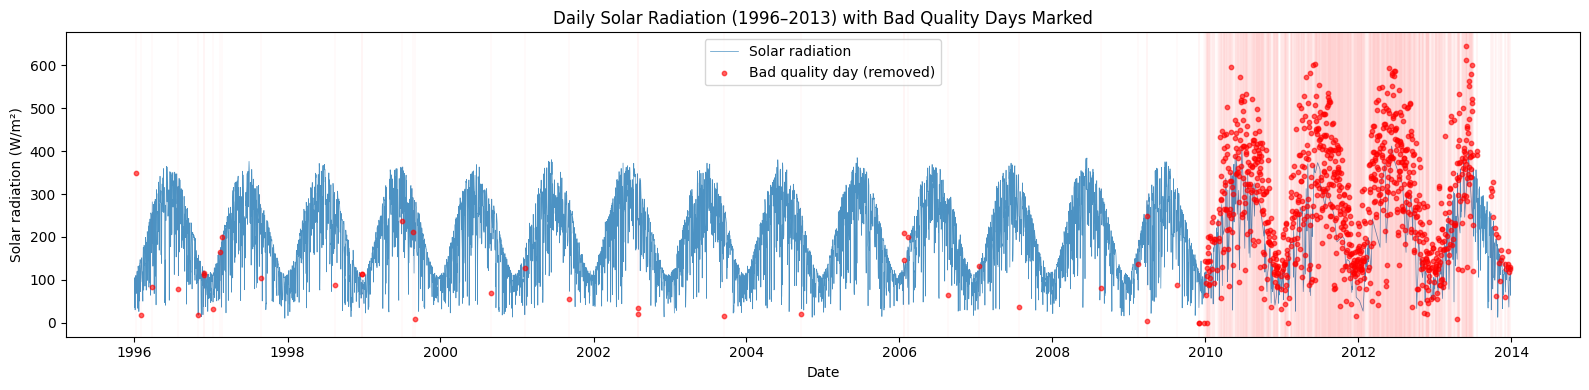

In [11]:
# Plot 1: Time-series with bad quality marked
fig, ax = plt.subplots(figsize=(16, 4))
good = df_with_bad[df_with_bad['bad_quality'] == 0]
bad = df_with_bad[df_with_bad['bad_quality'] == 1]
ax.plot(good['date'], good['solar_t'], linewidth=0.5, alpha=0.8, label='Solar radiation')
ax.scatter(bad['date'], bad['solar_t'], color='red', s=10, alpha=0.6,
           label='Bad quality day (removed)', zorder=5)
for d in bad['date']:
    ax.axvline(d, color='red', alpha=0.1, linewidth=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Solar radiation (W/m²)')
ax.set_title('Daily Solar Radiation (1996–2013) with Bad Quality Days Marked')
ax.legend()
plt.tight_layout()
plt.show()

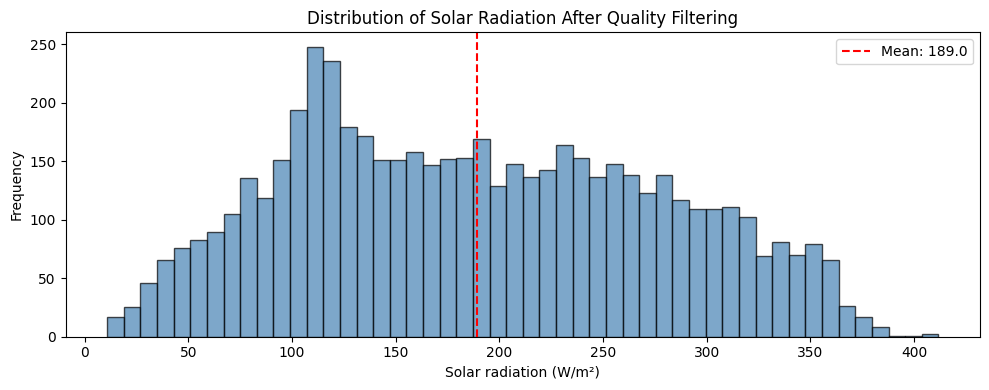

In [12]:
# Plot 2: Histogram of solar radiation after quality filtering
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['solar_t'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Solar radiation (W/m²)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Solar Radiation After Quality Filtering')
ax.axvline(df['solar_t'].mean(), color='red', linestyle='--', label=f"Mean: {df['solar_t'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

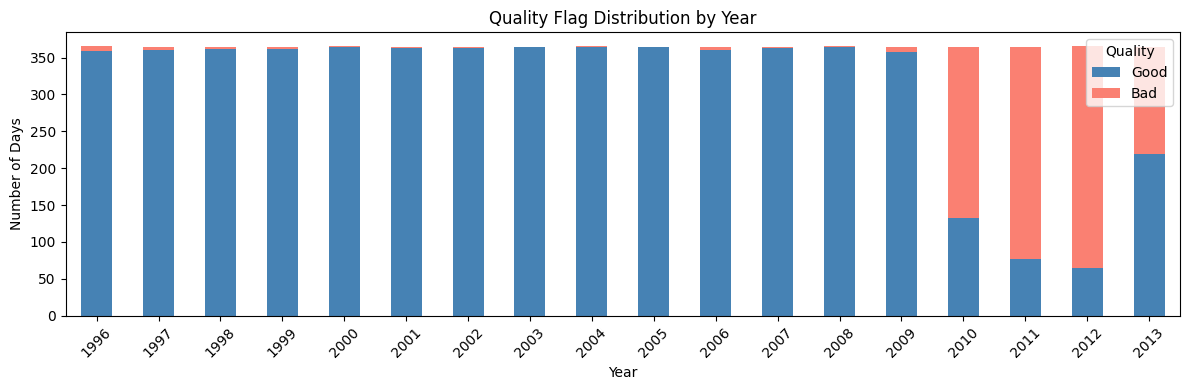

In [13]:
# Plot 3: Bar chart of good vs bad quality per year
df_with_bad['year'] = df_with_bad['date'].dt.year
quality_counts = df_with_bad.groupby(['year', 'bad_quality']).size().unstack(fill_value=0)
quality_counts.columns = ['Good', 'Bad']

fig, ax = plt.subplots(figsize=(12, 4))
quality_counts.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'salmon'])
ax.set_xlabel('Year')
ax.set_ylabel('Number of Days')
ax.set_title('Quality Flag Distribution by Year')
ax.legend(title='Quality')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part B: Multi-Output Model with Custom Loss Function

Build a single multi-output neural network and compare 3 custom loss functions:
1. Weighted MSE (baseline)
2. Pseudo-Huber Loss
3. Weighted Quantile Loss

All models use the same architecture, seed, learning rate, batch size, and early stopping.

### B.1 Model Architecture

Reference architecture:
- Input: 13 features
- Hidden: 2 × Dense(64, ReLU)
- Output: Dense(7, linear)

In [14]:
# Training hyperparameters
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 300
PATIENCE = 20

def build_mlp(input_dim, output_dim=7, name='mlp'):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu', name='hidden1'),
        layers.Dense(64, activation='relu', name='hidden2'),
        layers.Dense(output_dim, activation='linear', name='output'),
    ], name=name)
    return model

# Display architecture
sample_model = build_mlp(X_train.shape[1])
sample_model.summary()

Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,511 (21.53 KB)

 Trainable params: 5,511 (21.53 KB)

 Non-trainable params: 0 (0.00 B)

### B.2 Custom Loss Functions

1. **Weighted MSE**
2. **Pseudo-Huber**
3. **Weighted Quantile**

In [15]:
# Horizon weights: w_k = 1/sqrt(k) for k=1..7
horizon_weights = tf.constant([1.0 / np.sqrt(k) for k in range(1, 8)], dtype=tf.float32)

def weighted_mse_loss(y_true, y_pred):
    mse_per_horizon = tf.reduce_mean(tf.square(y_true - y_pred), axis=0)
    return tf.reduce_sum(horizon_weights * mse_per_horizon)

def pseudo_huber_loss(y_true, y_pred, delta=50.0):
    u = y_true - y_pred
    huber_per_sample = delta**2 * (tf.sqrt(1.0 + tf.square(u / delta)) - 1.0)
    huber_per_horizon = tf.reduce_mean(huber_per_sample, axis=0)
    return tf.reduce_sum(horizon_weights * huber_per_horizon)

def weighted_quantile_loss(y_true, y_pred, tau=0.8):
    u = y_true - y_pred
    # rho_tau(u) = u * (tau - I(u<0))
    quantile_per_sample = u * (tau - tf.cast(u < 0, tf.float32))
    quantile_per_horizon = tf.reduce_mean(quantile_per_sample, axis=0)
    return tf.reduce_sum(horizon_weights * quantile_per_horizon)

print("Loss functions defined: weighted_mse, pseudo_huber, weighted_quantile")

Loss functions defined: weighted_mse, pseudo_huber, weighted_quantile


### B.3 Training

Train 3 models with the same configuration, varying only the loss function.

In [16]:
# Training function
def train_model(build_fn, loss_fn, X_train, Y_train, X_val, Y_val,
                name='model', lr=LEARNING_RATE, batch_size=BATCH_SIZE,
                epochs=EPOCHS, patience=PATIENCE):
    """Train a model and return history."""
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_fn(X_train.shape[1])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss=loss_fn)

    early_stop = EarlyStopping(monitor='val_loss', patience=patience,
                               restore_best_weights=True, verbose=1)

    start_time = time.time()
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    train_time = time.time() - start_time

    print(f"{name} trained in {train_time:.1f}s, "
          f"epochs: {len(history.history['loss'])}, "
          f"best val_loss: {min(history.history['val_loss']):.4f}")

    return model, history, train_time

# Train 3 models
print("Training Model 1: Weighted MSE...")
model_wmse, hist_wmse, time_wmse = train_model(
    build_mlp, weighted_mse_loss, X_train, Y_train, X_val, Y_val, name='Weighted MSE')

print("\nTraining Model 2: Pseudo-Huber...")
model_huber, hist_huber, time_huber = train_model(
    build_mlp, pseudo_huber_loss, X_train, Y_train, X_val, Y_val, name='Pseudo-Huber')

print("\nTraining Model 3: Weighted Quantile...")
model_quantile, hist_quantile, time_quantile = train_model(
    build_mlp, weighted_quantile_loss, X_train, Y_train, X_val, Y_val, name='Weighted Quantile')

# Save models
model_wmse.save('models/model_wmse.keras')
model_huber.save('models/model_huber.keras')
model_quantile.save('models/model_quantile.keras')
print("\nAll Part B models saved.")

Training Model 1: Weighted MSE...
Epoch 219: early stopping
Restoring model weights from the end of the best epoch: 199.
Weighted MSE trained in 15.5s, epochs: 219, best val_loss: 15100.5410

Training Model 2: Pseudo-Huber...
Epoch 227: early stopping
Restoring model weights from the end of the best epoch: 207.
Pseudo-Huber trained in 15.9s, epochs: 227, best val_loss: 4603.1343

Training Model 3: Weighted Quantile...
Epoch 130: early stopping
Restoring model weights from the end of the best epoch: 110.
Weighted Quantile trained in 9.2s, epochs: 130, best val_loss: 51.4375

All Part B models saved.


### B.4 Training Curves

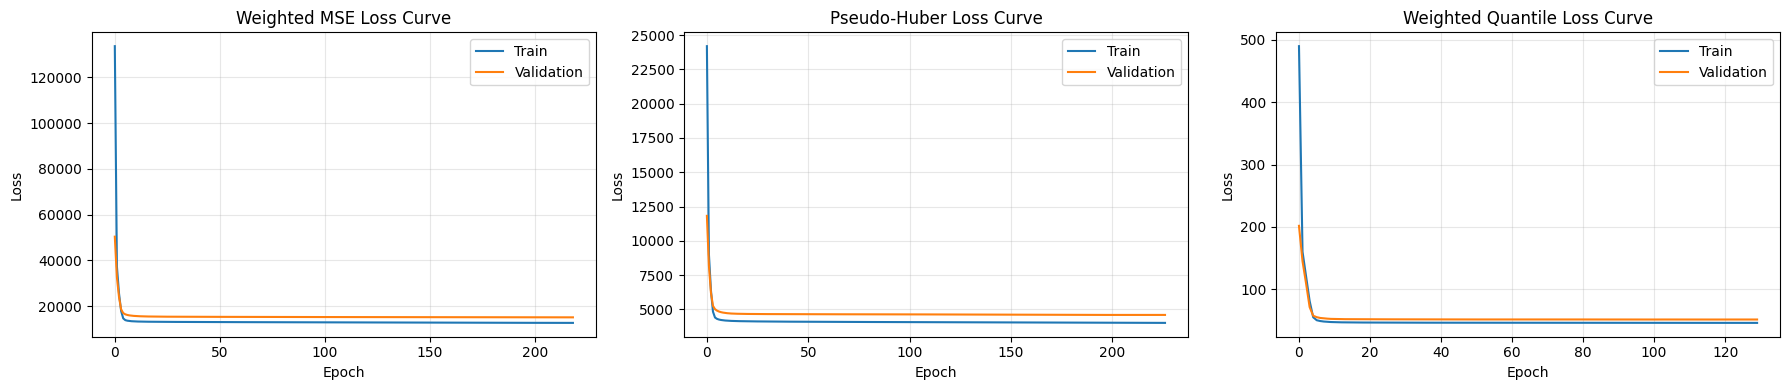

In [17]:
# Plot training and validation loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
histories = [('Weighted MSE', hist_wmse), ('Pseudo-Huber', hist_huber), ('Weighted Quantile', hist_quantile)]

for ax, (name, hist) in zip(axes, histories):
    ax.plot(hist.history['loss'], label='Train')
    ax.plot(hist.history['val_loss'], label='Validation')
    ax.set_title(f'{name} Loss Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### B.5 Evaluation

Evaluate on test set (2011–2013) with RMSE, MAE, MBE, P95 per horizon + macro-average.

In [18]:
# Evaluate all 3 models on test set
pred_wmse = model_wmse.predict(X_test, verbose=0)
pred_huber = model_huber.predict(X_test, verbose=0)
pred_quantile = model_quantile.predict(X_test, verbose=0)

print("=" * 60)
print("Weighted MSE Results:")
df_wmse = evaluate_model(Y_test, pred_wmse, include_bias=True)
print(df_wmse.to_string(index=False))

print("\n" + "=" * 60)
print("Pseudo-Huber Results:")
df_huber = evaluate_model(Y_test, pred_huber, include_bias=True)
print(df_huber.to_string(index=False))

print("\n" + "=" * 60)
print("Weighted Quantile Results:")
df_quantile = evaluate_model(Y_test, pred_quantile, include_bias=True)
print(df_quantile.to_string(index=False))

Weighted MSE Results:
  Horizon      RMSE       MAE       MBE        P95
      t+1 58.523978 45.243769 -0.995756 123.418840
      t+2 59.482338 46.561788 -4.312907 126.948960
      t+3 60.672558 47.571439 -3.592869 130.641650
      t+4 61.253318 47.972268 -2.061465 135.840794
      t+5 61.760016 47.885186 -2.918022 136.816890
      t+6 63.619960 49.030758 -1.889808 139.830232
      t+7 64.948546 50.513042 -5.877562 147.577836
Macro-Avg 61.465816 47.825464 -3.092627 134.439315

Pseudo-Huber Results:
  Horizon      RMSE       MAE      MBE        P95
      t+1 57.881184 44.038469 4.627515 119.164959
      t+2 59.688439 46.142446 2.811413 128.743741
      t+3 60.499889 46.600930 4.548564 132.492509
      t+4 61.391615 47.348683 5.156899 134.236793
      t+5 61.981003 47.228692 4.710696 136.419228
      t+6 63.650773 48.409237 5.390283 142.174997
      t+7 64.259984 49.331167 1.118092 141.906045
Macro-Avg 61.336127 47.014232 4.051923 133.591182

Weighted Quantile Results:
  Horizon      RMS

In [19]:
# Comparison table (macro averages)
comparison = pd.DataFrame({
    'Loss Function': ['Weighted MSE', 'Pseudo-Huber', 'Weighted Quantile'],
    'RMSE': [df_wmse.iloc[-1]['RMSE'], df_huber.iloc[-1]['RMSE'], df_quantile.iloc[-1]['RMSE']],
    'MAE': [df_wmse.iloc[-1]['MAE'], df_huber.iloc[-1]['MAE'], df_quantile.iloc[-1]['MAE']],
    'MBE': [df_wmse.iloc[-1]['MBE'], df_huber.iloc[-1]['MBE'], df_quantile.iloc[-1]['MBE']],
    'P95': [df_wmse.iloc[-1]['P95'], df_huber.iloc[-1]['P95'], df_quantile.iloc[-1]['P95']],
})
print("\nMacro-Average Comparison:")
print(comparison.to_string(index=False))


Macro-Average Comparison:
    Loss Function      RMSE       MAE       MBE        P95
     Weighted MSE 61.465816 47.825464 -3.092627 134.439315
     Pseudo-Huber 61.336127 47.014232  4.051923 133.591182
Weighted Quantile 77.875618 55.826819 45.432748 176.983948


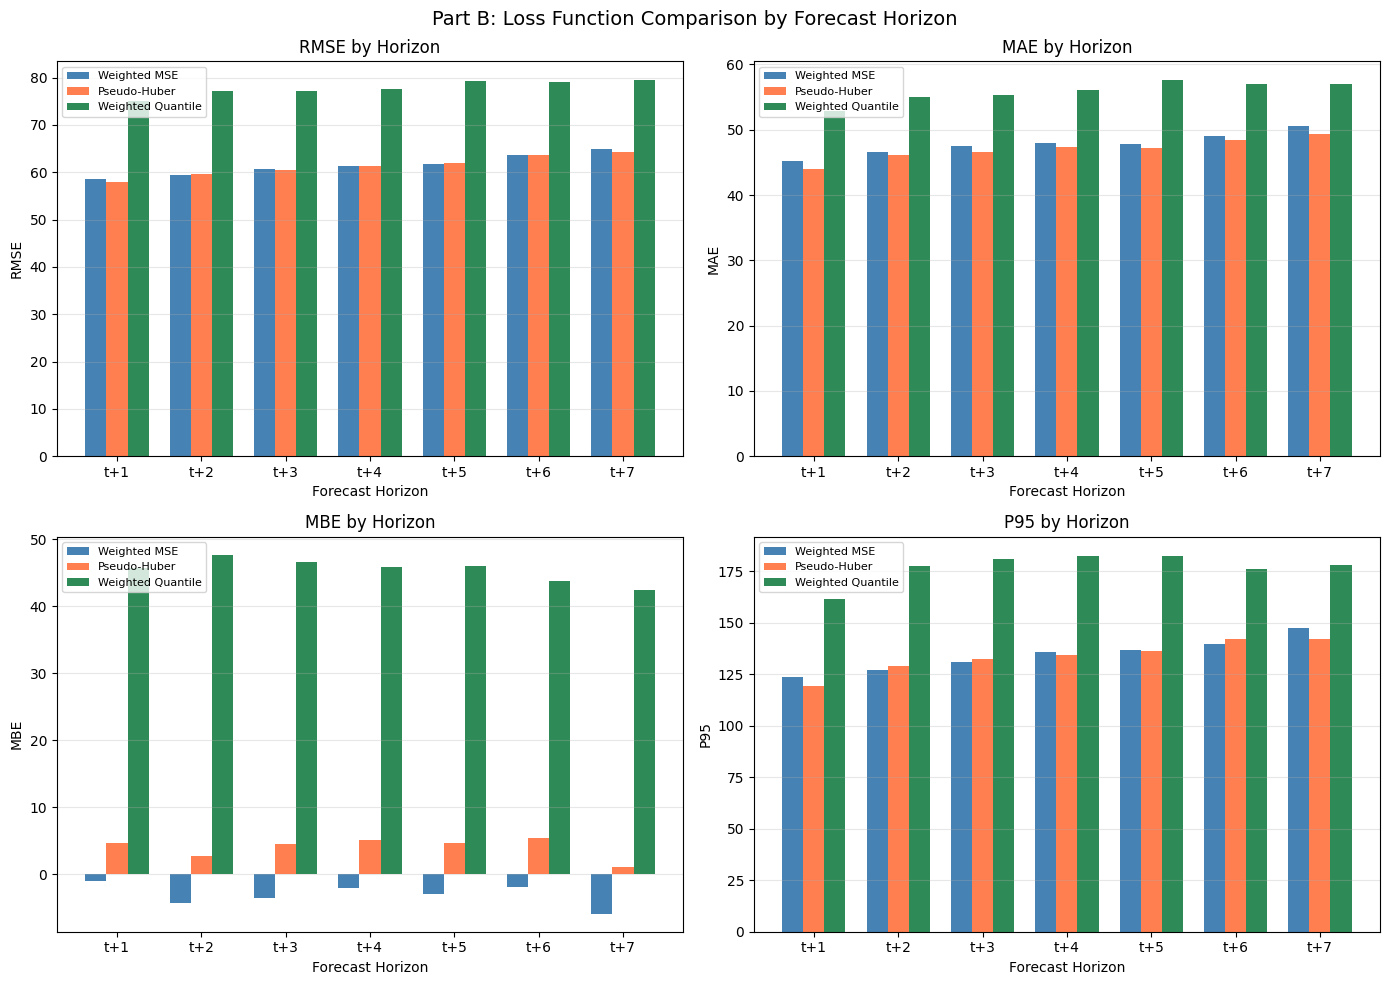

In [20]:
# Grouped bar chart: Metrics by horizon across loss functions

metrics_to_plot = ['RMSE', 'MAE', 'MBE', 'P95']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
horizons = [f't+{k}' for k in range(1, 8)]

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    x = np.arange(len(horizons))
    width = 0.25
    vals_wmse = df_wmse[df_wmse['Horizon'] != 'Macro-Avg'][metric].values
    vals_huber = df_huber[df_huber['Horizon'] != 'Macro-Avg'][metric].values
    vals_quant = df_quantile[df_quantile['Horizon'] != 'Macro-Avg'][metric].values

    ax.bar(x - width, vals_wmse, width, label='Weighted MSE', color='steelblue')
    ax.bar(x, vals_huber, width, label='Pseudo-Huber', color='coral')
    ax.bar(x + width, vals_quant, width, label='Weighted Quantile', color='seagreen')

    ax.set_xlabel('Forecast Horizon')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Horizon')
    ax.set_xticks(x)
    ax.set_xticklabels(horizons)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Part B: Loss Function Comparison by Forecast Horizon', fontsize=14)
plt.tight_layout()
plt.show()

## Part C: Individual Models and Transfer Learning

1. Seven separate single-output models
2. Strategy 1: Sequential fine-tuning
3. Strategy 2: Feature extraction
4. Strategy 3: Multi-task learning

### C.1 Seven Separate Models

Train 7 independent single-output models, each predicting one horizon (t+1 to t+7), using standard MSE loss.

In [21]:
# Train 7 individual models
individual_models = []
individual_histories = []
individual_times = []

for k in range(7):
    print(f"Training individual model for t+{k+1}...")
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='linear'),
    ], name=f'individual_t{k+1}')

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                               restore_best_weights=True, verbose=0)

    start_time = time.time()
    history = model.fit(
        X_train, Y_train[:, k:k+1],
        validation_data=(X_val, Y_val[:, k:k+1]),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[early_stop], verbose=0
    )
    elapsed = time.time() - start_time

    individual_models.append(model)
    individual_histories.append(history)
    individual_times.append(elapsed)
    model.save(f'models/individual_t{k+1}.keras')
    print(f"  t+{k+1}: {elapsed:.1f}s, best val_loss: {min(history.history['val_loss']):.4f}")

print("\nAll 7 individual models trained and saved.")

Training individual model for t+1...
  t+1: 4.9s, best val_loss: 3592.8125
Training individual model for t+2...
  t+2: 5.7s, best val_loss: 3874.9448
Training individual model for t+3...
  t+3: 4.2s, best val_loss: 3844.8835
Training individual model for t+4...
  t+4: 7.6s, best val_loss: 3900.4783
Training individual model for t+5...
  t+5: 6.5s, best val_loss: 3887.0525
Training individual model for t+6...
  t+6: 4.7s, best val_loss: 3933.1614
Training individual model for t+7...
  t+7: 3.4s, best val_loss: 3997.8574

All 7 individual models trained and saved.


In [22]:
# Evaluate individual models
pred_individual = np.zeros_like(Y_test)
for k in range(7):
    pred_individual[:, k] = individual_models[k].predict(X_test, verbose=0).flatten()

print("Individual Models Results:")
df_individual = evaluate_model(Y_test, pred_individual)
print(df_individual.to_string(index=False))

Individual Models Results:
  Horizon      RMSE       MAE
      t+1 58.351215 45.003560
      t+2 60.165106 46.941405
      t+3 61.155756 47.805806
      t+4 61.286310 47.780345
      t+5 61.761929 47.943153
      t+6 63.568758 49.077292
      t+7 64.943681 50.600009
Macro-Avg 61.604679 47.878796


### C.2 Strategy 1: Sequential Fine-Tuning

Train model for t+1, then use its weights to initialise model for t+2, and so on.

In [23]:
# Strategy 1: Sequential fine-tuning
seq_models = []
seq_times = []

for k in range(7):
    print(f"Sequential fine-tuning for t+{k+1}...")
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation='relu', name='hidden1'),
        layers.Dense(64, activation='relu', name='hidden2'),
        layers.Dense(1, activation='linear', name='output'),
    ], name=f'seq_t{k+1}')

    # Initialize from previous model's weights (except output layer for k>0)
    if k > 0:
        prev_model = seq_models[k-1]
        for layer_name in ['hidden1', 'hidden2']:
            model.get_layer(layer_name).set_weights(
                prev_model.get_layer(layer_name).get_weights()
            )

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')
    early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                               restore_best_weights=True, verbose=0)

    start_time = time.time()
    model.fit(X_train, Y_train[:, k:k+1],
              validation_data=(X_val, Y_val[:, k:k+1]),
              epochs=EPOCHS, batch_size=BATCH_SIZE,
              callbacks=[early_stop], verbose=0)
    elapsed = time.time() - start_time

    seq_models.append(model)
    seq_times.append(elapsed)
    model.save(f'models/seq_t{k+1}.keras')
    print(f"  t+{k+1}: {elapsed:.1f}s")

print("\nSequential fine-tuning complete.")

Sequential fine-tuning for t+1...
  t+1: 8.9s
Sequential fine-tuning for t+2...
  t+2: 6.5s
Sequential fine-tuning for t+3...
  t+3: 9.6s
Sequential fine-tuning for t+4...
  t+4: 5.6s
Sequential fine-tuning for t+5...
  t+5: 2.1s
Sequential fine-tuning for t+6...
  t+6: 2.2s
Sequential fine-tuning for t+7...
  t+7: 2.1s

Sequential fine-tuning complete.


In [24]:
# Evaluate Strategy 1
pred_seq = np.zeros_like(Y_test)
for k in range(7):
    pred_seq[:, k] = seq_models[k].predict(X_test, verbose=0).flatten()

print("Strategy 1 (Sequential Fine-Tuning) Results:")
df_seq = evaluate_model(Y_test, pred_seq)
print(df_seq.to_string(index=False))

Strategy 1 (Sequential Fine-Tuning) Results:
  Horizon      RMSE       MAE
      t+1 59.048169 45.465915
      t+2 59.899934 46.812791
      t+3 60.797494 47.531128
      t+4 61.052927 47.468526
      t+5 62.346211 48.097573
      t+6 63.778588 49.321047
      t+7 65.731989 51.077251
Macro-Avg 61.807902 47.967747


### C.3 Strategy 2: Feature Extraction

Train a model for t+1. For transfer to t+7: freeze all parameters except the output layer, then fine-tune only that layer. Report results for t+7 only.

In [25]:
# Strategy 2: Feature extraction (t+1 -> t+7)
print("Strategy 2: Feature Extraction")
print("Training base model for t+1...")

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Train t+1 base model
feat_base = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu', name='hidden1'),
    layers.Dense(64, activation='relu', name='hidden2'),
    layers.Dense(1, activation='linear', name='output'),
], name='feat_base')

feat_base.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                           restore_best_weights=True, verbose=0)

start_time = time.time()
feat_base.fit(X_train, Y_train[:, 0:1],
              validation_data=(X_val, Y_val[:, 0:1]),
              epochs=EPOCHS, batch_size=BATCH_SIZE,
              callbacks=[early_stop], verbose=0)
base_time = time.time() - start_time

# Transfer to t+7: freeze hidden layers, fine-tune output only
print("Transferring to t+7 (freeze hidden layers, fine-tune output)...")
feat_t7 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu', name='hidden1'),
    layers.Dense(64, activation='relu', name='hidden2'),
    layers.Dense(1, activation='linear', name='output'),
], name='feat_t7')

# Copy and freeze hidden weights
for layer_name in ['hidden1', 'hidden2']:
    feat_t7.get_layer(layer_name).set_weights(
        feat_base.get_layer(layer_name).get_weights())
    feat_t7.get_layer(layer_name).trainable = False

feat_t7.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                           restore_best_weights=True, verbose=0)

start_time = time.time()
feat_t7.fit(X_train, Y_train[:, 6:7],
            validation_data=(X_val, Y_val[:, 6:7]),
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            callbacks=[early_stop], verbose=0)
feat_time = time.time() - start_time

pred_feat_t7 = feat_t7.predict(X_test, verbose=0).flatten()
feat_t7.save('models/feat_extract_t7.keras')

print(f"\nStrategy 2 — t+7 Results:")
print(f"  RMSE: {calc_rmse(Y_test[:, 6], pred_feat_t7):.4f}")
print(f"  MAE:  {calc_mae(Y_test[:, 6], pred_feat_t7):.4f}")
print(f"  Training time (base + fine-tune): {base_time:.1f}s + {feat_time:.1f}s")

Strategy 2: Feature Extraction
Training base model for t+1...
Transferring to t+7 (freeze hidden layers, fine-tune output)...

Strategy 2 — t+7 Results:
  RMSE: 68.0546
  MAE:  52.6241
  Training time (base + fine-tune): 4.9s + 18.7s


### C.4 Strategy 3: Multi-Task Learning

Shared encoder with separate task-specific output heads (each with at least one hidden layer).

In [26]:
# Strategy 3: Multi-task learning with separate heads

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Build multi-task model using Functional API
inputs = layers.Input(shape=(X_train.shape[1],), name='input')

# Shared encoder
shared = layers.Dense(64, activation='relu', name='shared_hidden1')(inputs)
shared = layers.Dense(64, activation='relu', name='shared_hidden2')(shared)

# Separate heads for each horizon
outputs = []
for k in range(7):
    head = layers.Dense(32, activation='relu', name=f'head_{k+1}_hidden')(shared)
    out = layers.Dense(1, activation='linear', name=f'head_{k+1}_output')(head)
    outputs.append(out)

# Concatenate outputs to get (batch, 7)
output = layers.Concatenate(name='concat_outputs')(outputs)

model_multitask = Model(inputs=inputs, outputs=output, name='multi_task')
model_multitask.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                        loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                           restore_best_weights=True, verbose=1)

start_time = time.time()
hist_multitask = model_multitask.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop], verbose=0
)
multitask_time = time.time() - start_time
model_multitask.save('models/model_multitask.keras')

print(f"Multi-task model trained in {multitask_time:.1f}s")

# Evaluate
pred_multitask = model_multitask.predict(X_test, verbose=0)
print("\nStrategy 3 (Multi-Task Learning) Results:")
df_multitask = evaluate_model(Y_test, pred_multitask)
print(df_multitask.to_string(index=False))

Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 30.
Multi-task model trained in 7.4s

Strategy 3 (Multi-Task Learning) Results:
  Horizon      RMSE       MAE
      t+1 57.859681 45.630639
      t+2 58.861499 46.058662
      t+3 59.698405 46.634670
      t+4 60.927404 47.087780
      t+5 62.154933 48.344170
      t+6 63.607824 49.552258
      t+7 65.164923 50.941343
Macro-Avg 61.182096 47.749932


### C.5 Comparison

Compare Part B multi-output baseline, 7 individual models, Strategy 1, and Strategy 3.
Strategy 2 reports t+7 only.

In [27]:
# Build comparison table
comp_rows = []
model_names = ['Multi-Output (Part B)', 'Individual (7 models)',
               'Seq. Fine-Tune (S1)', 'Multi-Task (S3)']
preds_list = [pred_wmse, pred_individual, pred_seq, pred_multitask]
times_list = [time_wmse, sum(individual_times), sum(seq_times), multitask_time]

for name, preds, t in zip(model_names, preds_list, times_list):
    for k in range(7):
        comp_rows.append({
            'Model': name,
            'Horizon': f't+{k+1}',
            'RMSE': calc_rmse(Y_test[:, k], preds[:, k]),
            'MAE': calc_mae(Y_test[:, k], preds[:, k]),
            'Time (s)': t
        })

# Add Strategy 2 for t+7 only
comp_rows.append({
    'Model': 'Feature Extract (S2)',
    'Horizon': 't+7',
    'RMSE': calc_rmse(Y_test[:, 6], pred_feat_t7),
    'MAE': calc_mae(Y_test[:, 6], pred_feat_t7),
    'Time (s)': base_time + feat_time
})

df_comp = pd.DataFrame(comp_rows)
print("Part C Comparison Table (per horizon):")
print(df_comp.to_string(index=False))

Part C Comparison Table (per horizon):
                Model Horizon      RMSE       MAE  Time (s)
Multi-Output (Part B)     t+1 58.523978 45.243769 15.475165
Multi-Output (Part B)     t+2 59.482338 46.561788 15.475165
Multi-Output (Part B)     t+3 60.672558 47.571439 15.475165
Multi-Output (Part B)     t+4 61.253318 47.972268 15.475165
Multi-Output (Part B)     t+5 61.760016 47.885186 15.475165
Multi-Output (Part B)     t+6 63.619960 49.030758 15.475165
Multi-Output (Part B)     t+7 64.948546 50.513042 15.475165
Individual (7 models)     t+1 58.351215 45.003560 36.978451
Individual (7 models)     t+2 60.165106 46.941405 36.978451
Individual (7 models)     t+3 61.155756 47.805806 36.978451
Individual (7 models)     t+4 61.286310 47.780345 36.978451
Individual (7 models)     t+5 61.761929 47.943153 36.978451
Individual (7 models)     t+6 63.568758 49.077292 36.978451
Individual (7 models)     t+7 64.943681 50.600009 36.978451
  Seq. Fine-Tune (S1)     t+1 59.048169 45.465915 37.033088
 

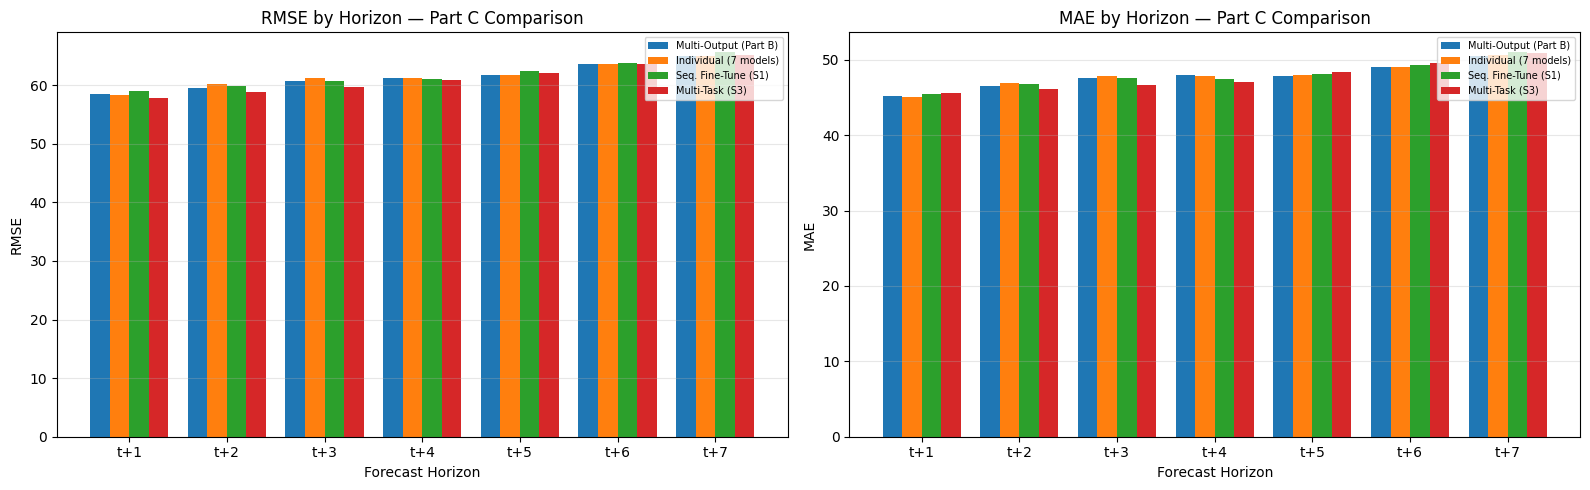

In [28]:
# Grouped bar chart: RMSE by horizon for each model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
horizons = [f't+{k}' for k in range(1, 8)]

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    x = np.arange(7)
    width = 0.2
    for i, name in enumerate(['Multi-Output (Part B)', 'Individual (7 models)',
                               'Seq. Fine-Tune (S1)', 'Multi-Task (S3)']):
        subset = df_comp[(df_comp['Model'] == name)]
        ax.bar(x + i*width, subset[metric].values, width, label=name)

    ax.set_xlabel('Forecast Horizon')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Horizon — Part C Comparison')
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(horizons)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Part D: Advanced Techniques

1. MC Dropout for uncertainty quantification
2. Attention mechanism with visualisation
3. Ablation study

### D.1 MC Dropout

Build multi-output model with Dropout(0.2) after each hidden layer (no BatchNorm).
At inference, keep dropout active and run T≥30 stochastic forward passes.

In [29]:
# MC Dropout Model
tf.random.set_seed(SEED)
np.random.seed(SEED)

mc_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(7, activation='linear'),
], name='mc_dropout')

mc_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                 loss=weighted_mse_loss)

early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                           restore_best_weights=True, verbose=1)

hist_mc = mc_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop], verbose=0
)

mc_model.save('models/model_mc_dropout.keras')
print("MC Dropout model trained.")

Epoch 66: early stopping
Restoring model weights from the end of the best epoch: 46.
MC Dropout model trained.


In [30]:
# MC Dropout inference: T=50 stochastic forward passes
T = 50
mc_predictions = np.array([mc_model(X_test, training=True).numpy() for _ in range(T)])
# mc_predictions shape: (T, n_samples, 7)

mc_mean = mc_predictions.mean(axis=0)  # (n_samples, 7)
mc_var = mc_predictions.var(axis=0)    # (n_samples, 7)
mc_std = np.sqrt(mc_var)

print("MC Dropout Results (using predictive mean):")
df_mc = evaluate_model(Y_test, mc_mean)
print(df_mc.to_string(index=False))

MC Dropout Results (using predictive mean):
  Horizon      RMSE       MAE
      t+1 57.854287 45.436643
      t+2 58.711988 46.112427
      t+3 59.884606 47.044267
      t+4 61.051381 47.535629
      t+5 62.888953 48.836420
      t+6 64.471797 49.996163
      t+7 65.617125 51.367972
Macro-Avg 61.497162 48.047074


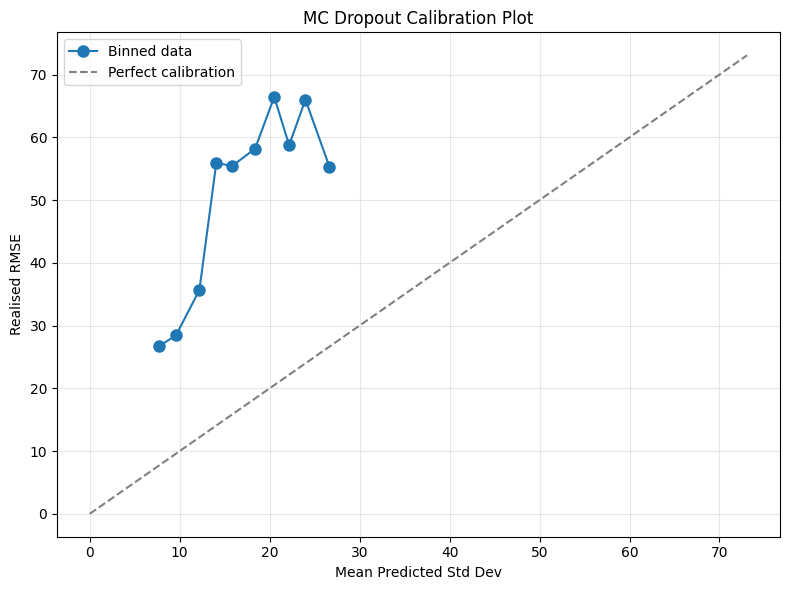

In [31]:
# Calibration plot: predicted std vs realised RMSE
fig, ax = plt.subplots(figsize=(8, 6))

# Average std and error across horizons per sample
mean_std_per_sample = mc_std.mean(axis=1)  # (n_samples,)
mean_abs_error_per_sample = np.abs(Y_test - mc_mean).mean(axis=1)

# Bin by predicted std
n_bins = 10
bins = np.percentile(mean_std_per_sample, np.linspace(0, 100, n_bins + 1))
bin_indices = np.digitize(mean_std_per_sample, bins) - 1
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

bin_pred_std = []
bin_realised_rmse = []
for b in range(n_bins):
    mask = bin_indices == b
    if mask.sum() > 0:
        bin_pred_std.append(mean_std_per_sample[mask].mean())
        bin_realised_rmse.append(np.sqrt(np.mean(mean_abs_error_per_sample[mask]**2)))

ax.plot(bin_pred_std, bin_realised_rmse, 'o-', markersize=8, label='Binned data')
lims = [0, max(max(bin_pred_std), max(bin_realised_rmse)) * 1.1]
ax.plot(lims, lims, '--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Std Dev')
ax.set_ylabel('Realised RMSE')
ax.set_title('MC Dropout Calibration Plot')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### D.2 Attention Mechanism

Reshape 7 lag features into a sequence of length 7. Apply linear projections to create Q, K, V, then scaled dot-product attention. Concatenate attention output with non-lag features.

In [32]:
# Attention Model using tf.keras.Model subclassing

class AttentionModel(Model):
    def __init__(self, n_non_lag_features, d_k=16, **kwargs):
        super().__init__(**kwargs)
        self.d_k = d_k
        self.n_non_lag = n_non_lag_features

        # Linear projections for Q, K, V
        self.W_q = layers.Dense(d_k, use_bias=False, name='W_q')
        self.W_k = layers.Dense(d_k, use_bias=False, name='W_k')
        self.W_v = layers.Dense(d_k, use_bias=False, name='W_v')

        # Output layers
        self.dense1 = layers.Dense(64, activation='relu', name='dense1')
        self.dense2 = layers.Dense(64, activation='relu', name='dense2')
        self.output_layer = layers.Dense(7, activation='linear', name='output_dense')

    def call(self, inputs, return_attention=False):
        # Split: non-lag features (first 6: day_sin, day_cos, 4 rolling stats)
        # and lag features (last 7: solar_t-1 to solar_t-7)
        non_lag = inputs[:, :self.n_non_lag]  # (batch, 6)
        lag = inputs[:, self.n_non_lag:]       # (batch, 7)

        # Reshape lags to sequence: (batch, 7, 1)
        lag_seq = tf.expand_dims(lag, axis=-1)  # (batch, 7, 1)

        # Q, K, V projections: (batch, 7, d_k)
        Q = self.W_q(lag_seq)
        K = self.W_k(lag_seq)
        V = self.W_v(lag_seq)

        # Scaled dot-product attention
        scores = tf.matmul(Q, K, transpose_b=True) / tf.sqrt(tf.cast(self.d_k, tf.float32))
        # scores: (batch, 7, 7)
        attn_weights = tf.nn.softmax(scores, axis=-1)  # (batch, 7, 7)
        attn_output = tf.matmul(attn_weights, V)  # (batch, 7, d_k)

        # Flatten attention output
        attn_flat = tf.reshape(attn_output, [-1, 7 * self.d_k])  # (batch, 7*d_k)

        # Concatenate with non-lag features
        combined = tf.concat([attn_flat, non_lag], axis=-1)

        # Output layers
        x = self.dense1(combined)
        x = self.dense2(x)
        output = self.output_layer(x)

        if return_attention:
            return output, attn_weights
        return output
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'd_k': self.d_k,
            'n_non_lag_features': self.n_non_lag,
        })
        return config

# Number of non-lag features: day_sin, day_cos, solar_mean_7d, solar_std_7d, solar_min_7d, solar_max_7d = 6
n_non_lag = 6

tf.random.set_seed(SEED)
np.random.seed(SEED)

attn_model = AttentionModel(n_non_lag_features=n_non_lag, d_k=16, name='attention')

# Build model by calling it once
_ = attn_model(X_train[:1].astype(np.float32))

attn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                   loss=weighted_mse_loss)

early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                           restore_best_weights=True, verbose=1)

hist_attn = attn_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop], verbose=0
)

attn_model.save('models/model_attention.keras')
print("Attention model trained and saved.")

Epoch 59: early stopping
Restoring model weights from the end of the best epoch: 39.
Attention model trained and saved.


In [33]:
# Evaluate attention model
pred_attn = attn_model.predict(X_test, verbose=0)
print("Attention Model Results:")
df_attn = evaluate_model(Y_test, pred_attn)
print(df_attn.to_string(index=False))

Attention Model Results:
  Horizon      RMSE       MAE
      t+1 57.601879 45.021944
      t+2 58.858184 46.118088
      t+3 59.765964 46.941090
      t+4 60.885552 47.244012
      t+5 62.405612 48.481975
      t+6 63.899522 49.315440
      t+7 65.001420 50.811808
Macro-Avg 61.202590 47.704908


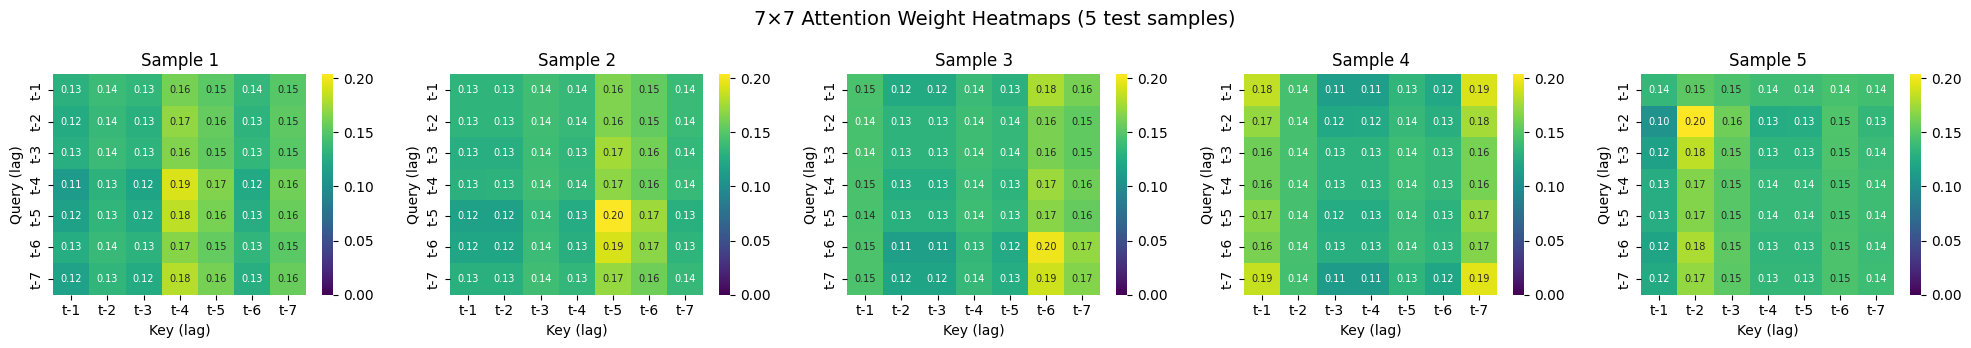

In [34]:
# Visualise attention weights for 5+ samples
_, attn_weights = attn_model(X_test[:10].astype(np.float32), return_attention=True)
attn_w = attn_weights.numpy()  # (10, 7, 7)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
lag_labels = [f't-{k}' for k in range(1, 8)]

for i, ax in enumerate(axes):
    sns.heatmap(attn_w[i], ax=ax, cmap='viridis',
                xticklabels=lag_labels, yticklabels=lag_labels,
                vmin=0, vmax=attn_w[:5].max(),
                annot=True, fmt='.2f', annot_kws={'size': 7})
    ax.set_title(f'Sample {i+1}')
    ax.set_xlabel('Key (lag)')
    ax.set_ylabel('Query (lag)')

plt.suptitle('7×7 Attention Weight Heatmaps (5 test samples)', fontsize=14)
plt.tight_layout()
plt.show()

### D.3 Ablation Study

Using the attention model as baseline, systematically remove components:
1. Remove Fourier features
2. Remove rolling statistics
3. Remove lagged features → fall back to standard MLP
4. Remove attention mechanism → standard MLP with all features

In [35]:

# Ablation study
# Feature groups:
# Non-lag: [day_sin, day_cos, solar_mean_7d, solar_std_7d, solar_min_7d, solar_max_7d]
# Lag: [solar_t-1, ..., solar_t-7]

# Feature indices
fourier_idx = [0, 1]          # day_sin, day_cos
rolling_idx = [2, 3, 4, 5]    # solar_mean_7d, std, min, max
lag_idx = [6, 7, 8, 9, 10, 11, 12]  # solar_t-1 to t-7

ablation_configs = {
    'full_attention': {'features': list(range(13)), 'use_attention': True, 'n_non_lag': 6},
    'no_fourier': {'features': rolling_idx + lag_idx, 'use_attention': True, 'n_non_lag': 4},
    'no_rolling_stats': {'features': fourier_idx + lag_idx, 'use_attention': True, 'n_non_lag': 2},
    'no_lag_features': {'features': fourier_idx + rolling_idx, 'use_attention': False, 'n_non_lag': None},
    'no_attention': {'features': list(range(13)), 'use_attention': False, 'n_non_lag': None},
}

ablation_results = {}

for name, config in ablation_configs.items():
    print(f"\nTraining ablation: {name}")
    feat_idx = config['features']
    X_tr_abl = X_train[:, feat_idx]
    X_va_abl = X_val[:, feat_idx]
    X_te_abl = X_test[:, feat_idx]

    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    if config['use_attention']:
        m = AttentionModel(n_non_lag_features=config['n_non_lag'], d_k=16, name=f'abl_{name}')
        _ = m(X_tr_abl[:1].astype(np.float32))
    else:
        m = keras.Sequential([
            layers.Input(shape=(len(feat_idx),)),
            layers.Dense(64, activation='relu'),
            layers.Dense(64, activation='relu'),
            layers.Dense(7, activation='linear'),
        ], name=f'abl_{name}')

    m.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss=weighted_mse_loss)

    early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                               restore_best_weights=True, verbose=0)
    m.fit(X_tr_abl, Y_train, validation_data=(X_va_abl, Y_val),
          epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop], verbose=0)

    pred = m.predict(X_te_abl, verbose=0)
    rmse_avg = np.mean([calc_rmse(Y_test[:, k], pred[:, k]) for k in range(7)])
    mae_avg = np.mean([calc_mae(Y_test[:, k], pred[:, k]) for k in range(7)])
    ablation_results[name] = {'RMSE': rmse_avg, 'MAE': mae_avg}
    print(f"  Macro RMSE: {rmse_avg:.4f}, MAE: {mae_avg:.4f}")

print("\nAblation study complete.")



Training ablation: full_attention
  Macro RMSE: 61.1881, MAE: 47.6738

Training ablation: no_fourier
  Macro RMSE: 69.2103, MAE: 52.7566

Training ablation: no_rolling_stats
  Macro RMSE: 60.9911, MAE: 47.5473

Training ablation: no_lag_features
  Macro RMSE: 61.1123, MAE: 47.6243

Training ablation: no_attention
  Macro RMSE: 61.4592, MAE: 47.7638

Ablation study complete.


                       RMSE        MAE
Config                                
full_attention    61.188069  47.673846
no_fourier        69.210344  52.756562
no_rolling_stats  60.991065  47.547332
no_lag_features   61.112315  47.624328
no_attention      61.459234  47.763814


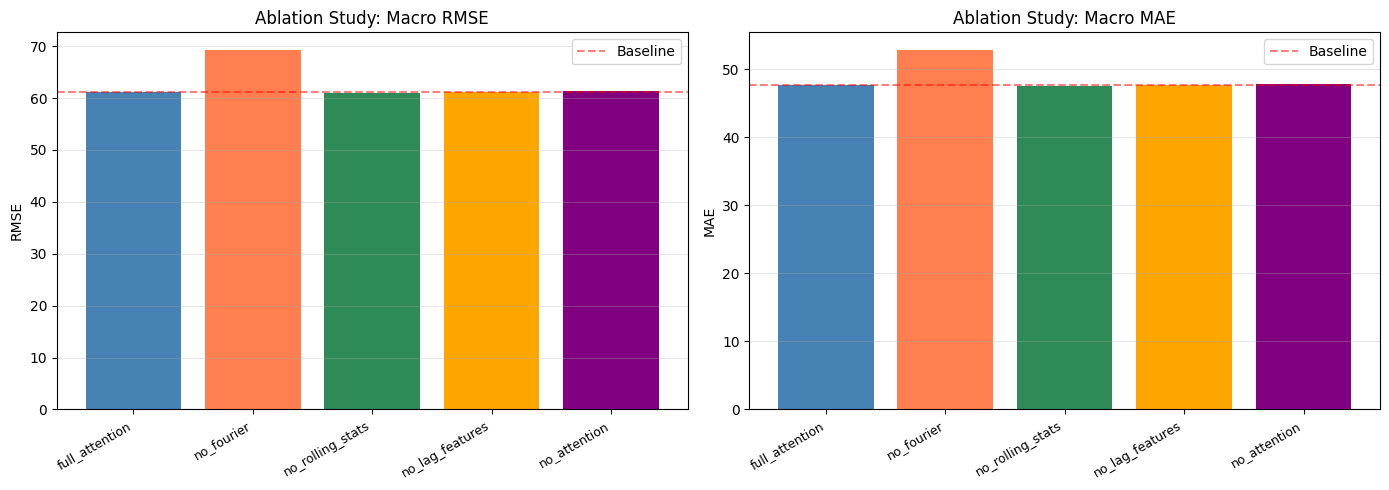

In [36]:
# Ablation bar chart
abl_df = pd.DataFrame(ablation_results).T
abl_df.index.name = 'Config'
print(abl_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.bar(range(len(abl_df)), abl_df[metric].values,
                  color=['steelblue', 'coral', 'seagreen', 'orange', 'purple'])
    ax.set_xticks(range(len(abl_df)))
    ax.set_xticklabels(abl_df.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(f'Ablation Study: Macro {metric}')
    ax.grid(True, alpha=0.3, axis='y')

    # Add baseline reference line
    baseline = abl_df.loc['full_attention', metric]
    ax.axhline(baseline, color='red', linestyle='--', alpha=0.5, label='Baseline')
    ax.legend()

plt.tight_layout()
plt.show()

## Part E: Statistical Analysis and Discussion

1. Paired t-tests on per-day mean absolute errors
2. Error analysis by season, horizon, weather condition, magnitude

### E.1 Statistical Significance Testing

Perform paired t-tests on per-day mean absolute errors (averaged across 7 horizons).

In [37]:
# Per-day mean absolute error for each model
def per_day_mae(y_true, y_pred):
    """Mean absolute error per sample, averaged across horizons."""
    return np.mean(np.abs(y_true - y_pred), axis=1)  # (n_samples,)

mae_multioutput = per_day_mae(Y_test, pred_wmse)
mae_individual = per_day_mae(Y_test, pred_individual)
mae_attention = per_day_mae(Y_test, pred_attn)
mae_multitask_daily = per_day_mae(Y_test, pred_multitask)

def paired_ttest(errors_a, errors_b, name_a, name_b):
    """Perform paired t-test and report results."""
    d = errors_a - errors_b
    d_bar = np.mean(d)
    s_d = np.std(d, ddof=1)
    n = len(d)
    t_stat = d_bar / (s_d / np.sqrt(n))
    # Two-tailed p-value
    p_val = 2 * stats.t.sf(np.abs(t_stat), df=n-1)
    # 95% CI for mean difference
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_low = d_bar - t_crit * (s_d / np.sqrt(n))
    ci_high = d_bar + t_crit * (s_d / np.sqrt(n))

    print(f"\n{name_a} vs {name_b}:")
    print(f"  Mean difference (d̄): {d_bar:.6f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.6f}")
    print(f"  95% CI: [{ci_low:.6f}, {ci_high:.6f}]")
    sig = "significant" if p_val < 0.05 else "not significant"
    print(f"  → Difference is {sig} at α=0.05")
    return t_stat, p_val, ci_low, ci_high

print("=" * 60)
print("Paired t-tests on per-day mean absolute errors")
print("=" * 60)

# (i) Multi-output vs Individual
paired_ttest(mae_multioutput, mae_individual, 'Multi-Output', 'Individual')

# (ii) Attention vs Multi-output
paired_ttest(mae_attention, mae_multioutput, 'Attention', 'Multi-Output')

# (iii) Multi-output vs Multi-task
paired_ttest(mae_multioutput, mae_multitask_daily, 'Multi-Output', 'Multi-Task')

Paired t-tests on per-day mean absolute errors

Multi-Output vs Individual:
  Mean difference (d̄): -0.053331
  t-statistic: -0.3157
  p-value: 0.752405
  95% CI: [-0.385571, 0.278908]
  → Difference is not significant at α=0.05

Attention vs Multi-Output:
  Mean difference (d̄): -0.120556
  t-statistic: -0.5686
  p-value: 0.569965
  95% CI: [-0.537537, 0.296425]
  → Difference is not significant at α=0.05

Multi-Output vs Multi-Task:
  Mean difference (d̄): 0.075533
  t-statistic: 0.4315
  p-value: 0.666368
  95% CI: [-0.268751, 0.419816]
  → Difference is not significant at α=0.05


(np.float64(0.43150767561614295),
 np.float64(0.6663680136652338),
 np.float64(-0.268750823630591),
 np.float64(0.4198161623081801))

### E.2 Error Analysis

Analyse errors along multiple dimensions:
1. **Season**: Winter(Dec-Feb), Spring(Mar-May), Summer(Jun-Aug), Autumn(Sep-Nov)
2. **Horizon**: Short-term(t+1~t+3) vs Long-term(t+4~t+7)
3. **Weather conditions**: Clear(>75th pct), Cloudy(<25th pct), Mixed(between)
4. **Magnitude**: Low/Medium/High by training set terciles

In [38]:
# Error analysis helper
# Use the multi-output (weighted MSE) model as the main model for analysis
pred_main = pred_wmse

# Per-day per-horizon absolute errors
abs_errors = np.abs(Y_test - pred_main)  # (n_samples, 7)
# Mean across horizons for each day
daily_mean_rmse = np.sqrt(np.mean((Y_test - pred_main)**2, axis=1))
daily_mean_mae_arr = np.mean(abs_errors, axis=1)

# Build test dataframe for grouping
df_analysis = pd.DataFrame({
    'date': dates_test,
    'solar_t': solar_t_test,
    'mae': daily_mean_mae_arr,
    'rmse': daily_mean_rmse,
})
df_analysis['date'] = pd.to_datetime(df_analysis['date'])
df_analysis['month'] = df_analysis['date'].dt.month

# 1. Season assignment (Northern Hemisphere)
def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_analysis['season'] = df_analysis['month'].apply(assign_season)

# 2. Weather conditions based on training data quartiles
q25 = np.percentile(solar_t_train, 25)
q75 = np.percentile(solar_t_train, 75)
def assign_weather(val):
    if val > q75:
        return 'Clear'
    elif val < q25:
        return 'Cloudy'
    else:
        return 'Mixed'

df_analysis['weather'] = df_analysis['solar_t'].apply(assign_weather)

# 3. Magnitude by training terciles
t33 = np.percentile(solar_t_train, 33.33)
t66 = np.percentile(solar_t_train, 66.67)
def assign_magnitude(val):
    if val <= t33:
        return 'Low'
    elif val <= t66:
        return 'Medium'
    else:
        return 'High'

df_analysis['magnitude'] = df_analysis['solar_t'].apply(assign_magnitude)
print("Analysis dataframe created.")
print(f"Training quartiles: Q25={q25:.2f}, Q75={q75:.2f}")
print(f"Training terciles: T33={t33:.2f}, T66={t66:.2f}")

Analysis dataframe created.
Training quartiles: Q25=116.00, Q75=259.36
Training terciles: T33=135.49, T66=233.71


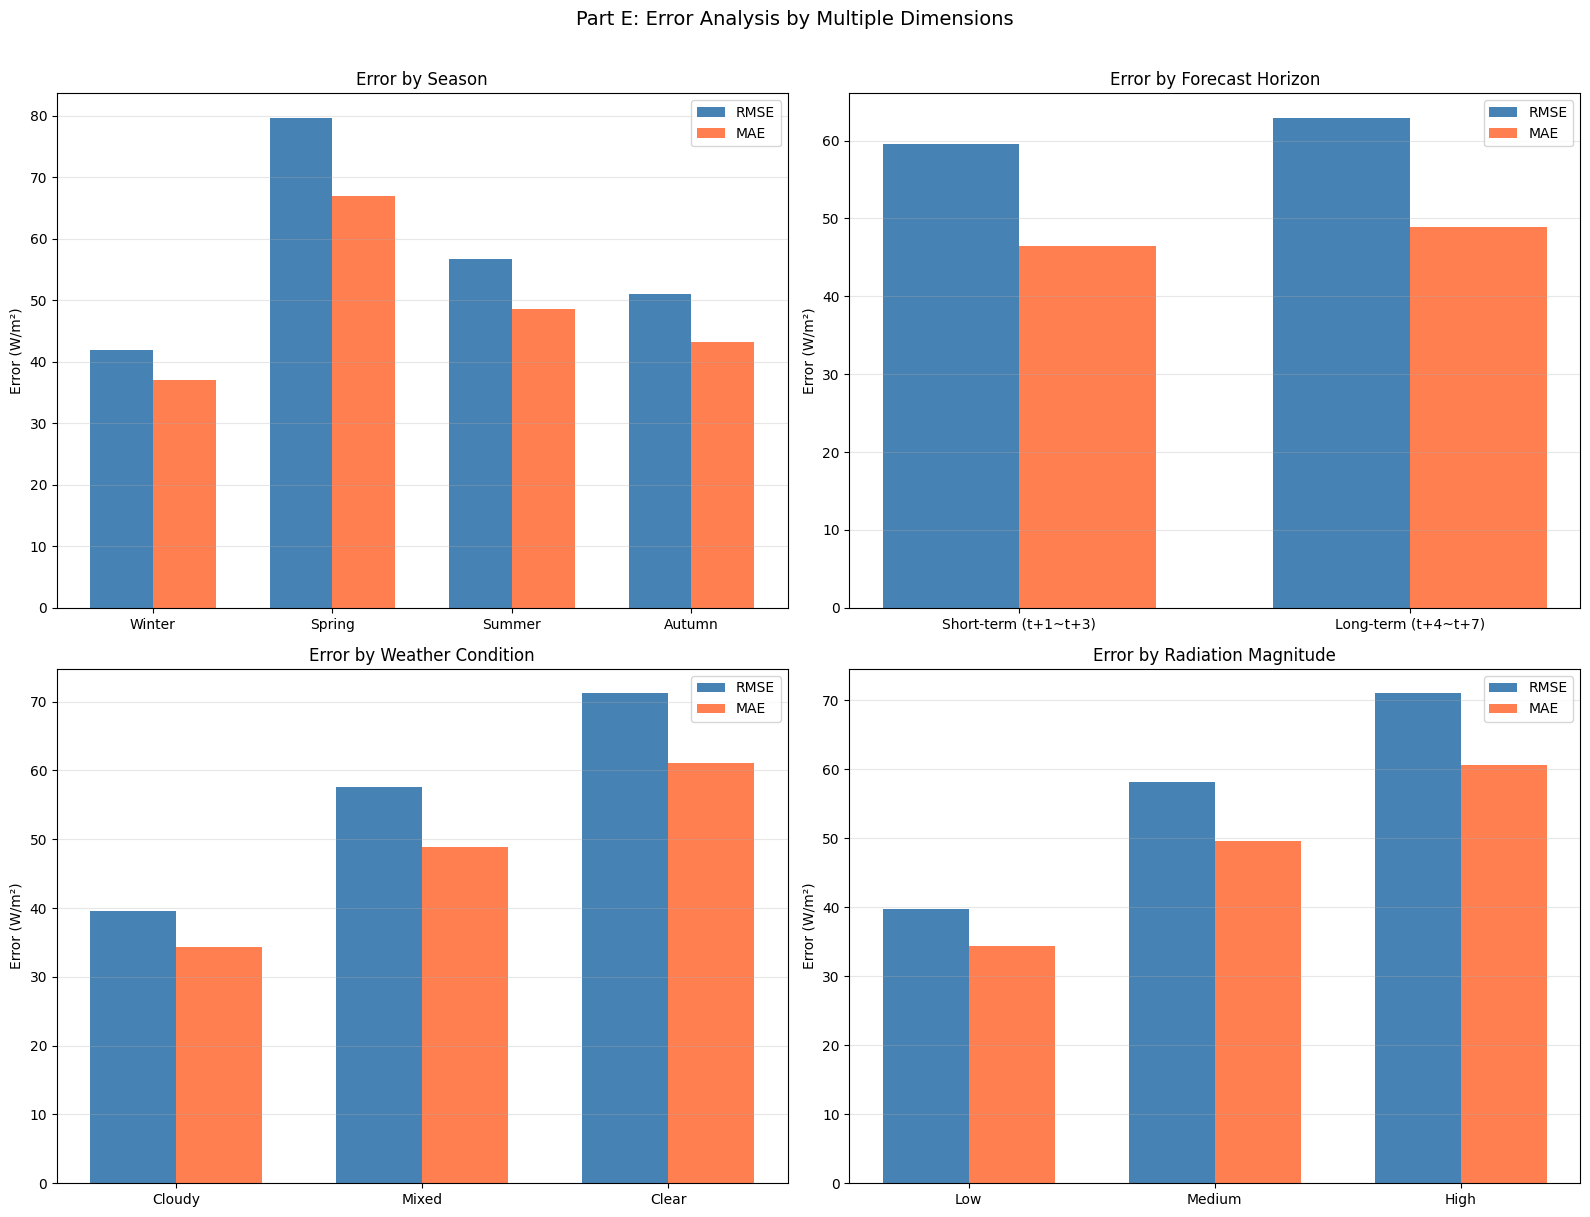

In [39]:
# Error analysis plots

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. By Season
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_stats = df_analysis.groupby('season')[['rmse', 'mae']].mean().reindex(season_order)
x = np.arange(len(season_order))
width = 0.35
axes[0, 0].bar(x - width/2, season_stats['rmse'], width, label='RMSE', color='steelblue')
axes[0, 0].bar(x + width/2, season_stats['mae'], width, label='MAE', color='coral')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(season_order)
axes[0, 0].set_title('Error by Season')
axes[0, 0].set_ylabel('Error (W/m²)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. By Horizon (short-term vs long-term)
short_rmse = np.sqrt(np.mean((Y_test[:, :3] - pred_main[:, :3])**2))
long_rmse = np.sqrt(np.mean((Y_test[:, 3:] - pred_main[:, 3:])**2))
short_mae = np.mean(np.abs(Y_test[:, :3] - pred_main[:, :3]))
long_mae = np.mean(np.abs(Y_test[:, 3:] - pred_main[:, 3:]))

x = np.arange(2)
axes[0, 1].bar(x - width/2, [short_rmse, long_rmse], width, label='RMSE', color='steelblue')
axes[0, 1].bar(x + width/2, [short_mae, long_mae], width, label='MAE', color='coral')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(['Short-term (t+1~t+3)', 'Long-term (t+4~t+7)'])
axes[0, 1].set_title('Error by Forecast Horizon')
axes[0, 1].set_ylabel('Error (W/m²)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. By Weather Condition
weather_order = ['Cloudy', 'Mixed', 'Clear']
weather_stats = df_analysis.groupby('weather')[['rmse', 'mae']].mean().reindex(weather_order)
x = np.arange(len(weather_order))
axes[1, 0].bar(x - width/2, weather_stats['rmse'], width, label='RMSE', color='steelblue')
axes[1, 0].bar(x + width/2, weather_stats['mae'], width, label='MAE', color='coral')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(weather_order)
axes[1, 0].set_title('Error by Weather Condition')
axes[1, 0].set_ylabel('Error (W/m²)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. By Magnitude
mag_order = ['Low', 'Medium', 'High']
mag_stats = df_analysis.groupby('magnitude')[['rmse', 'mae']].mean().reindex(mag_order)
x = np.arange(len(mag_order))
axes[1, 1].bar(x - width/2, mag_stats['rmse'], width, label='RMSE', color='steelblue')
axes[1, 1].bar(x + width/2, mag_stats['mae'], width, label='MAE', color='coral')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(mag_order)
axes[1, 1].set_title('Error by Radiation Magnitude')
axes[1, 1].set_ylabel('Error (W/m²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Part E: Error Analysis by Multiple Dimensions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 6: Hidden Test Set Evaluation

**This cell should be left unexecuted at submission time.**
Hidden data (2014–2019) will be provided before the discussion session.

Hidden test set: 334 samples
Date range: 2011-02-21 00:00:00 to 2013-12-22 00:00:00

Hidden Test Set Results

Multi-Output (Weighted MSE):
  Horizon      RMSE       MAE
      t+1 59.118294 45.557400
      t+2 59.987733 46.759174
      t+3 61.197782 47.787575
      t+4 61.824432 48.226301
      t+5 62.362378 48.197160
      t+6 64.241738 49.346749
      t+7 65.148300 50.461131
Macro-Avg 61.982951 48.047927

Individual Models:
  Horizon      RMSE       MAE
      t+1 58.928321 45.283628
      t+2 60.667035 47.095012
      t+3 61.698839 47.994982
      t+4 61.923188 48.094322
      t+5 62.428278 48.311992
      t+6 64.264241 49.491578
      t+7 65.289879 50.707085
Macro-Avg 62.171397 48.139800

Attention Model:
  Horizon      RMSE       MAE
      t+1 58.186675 45.323296
      t+2 59.423006 46.364548
      t+3 60.367307 47.218709
      t+4 61.507909 47.547411
      t+5 63.031241 48.786810
      t+6 64.579999 49.681751
      t+7 65.287064 50.849963
Macro-Avg 61.769029 47.967498

Multi-Task M

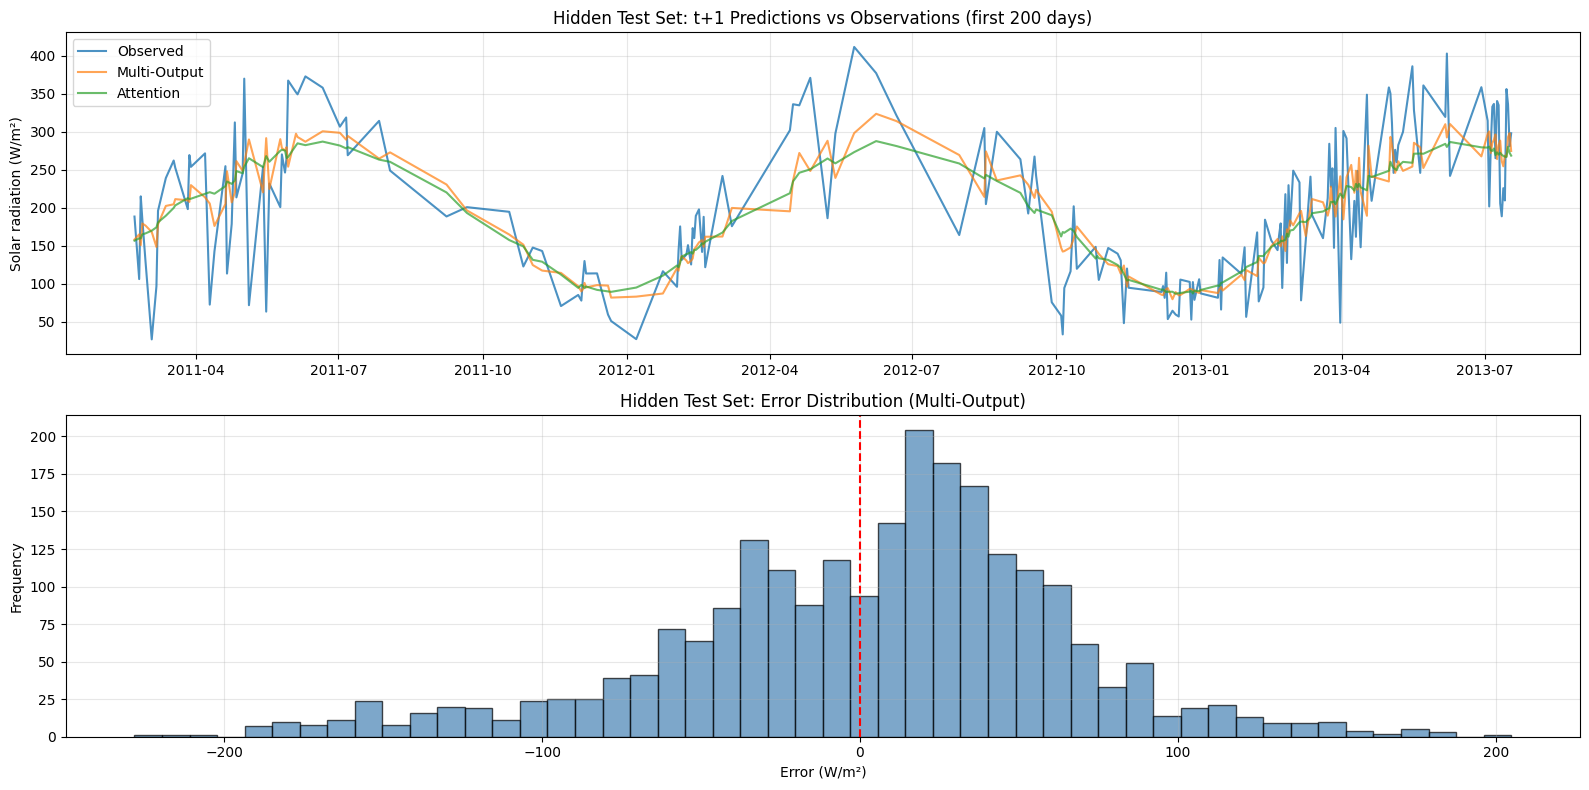

In [40]:
# ==================== HIDDEN TEST SET EVALUATION ====================
# Run this cell when hidden data (daily_solar_2014.csv to daily_solar_2019.csv) is available.

# 1. Load data
hidden_dfs = []
for year in range(2011, 2014):# Switch to 2014-2019 during discussion
    filepath = f'datasets/daily_solar_{year}.csv'
    if os.path.exists(filepath):
        hidden_dfs.append(pd.read_csv(filepath))
    else:
        print(f"Warning: {filepath} not found")

if hidden_dfs:
    df_hidden = pd.concat(hidden_dfs, ignore_index=True)
    df_hidden['date'] = pd.to_datetime(df_hidden['date'])
    df_hidden = df_hidden.sort_values('date').reset_index(drop=True)

    # Remove bad quality
    df_hidden = df_hidden[df_hidden['bad_quality'] == 0].reset_index(drop=True)

    # 2. Feature engineering
    df_hidden = add_fourier_features(df_hidden)

    # Rolling statistics
    df_hidden['solar_mean_7d'] = df_hidden['solar_t'].rolling(7, min_periods=7).mean()
    df_hidden['solar_std_7d'] = df_hidden['solar_t'].rolling(7, min_periods=7).std(ddof=1)
    df_hidden['solar_min_7d'] = df_hidden['solar_t'].rolling(7, min_periods=7).min()
    df_hidden['solar_max_7d'] = df_hidden['solar_t'].rolling(7, min_periods=7).max()
    df_hidden = df_hidden.dropna(subset=['solar_mean_7d']).reset_index(drop=True)

    # Lag features
    for k in range(1, 8):
        df_hidden[f'solar_t-{k}'] = df_hidden['solar_t'].shift(k)

    # Target variables
    for k in range(1, 8):
        df_hidden[f'target_t+{k}'] = df_hidden['solar_t'].shift(-k)

    df_hidden = df_hidden.dropna().reset_index(drop=True)

    # Drop first 7 rows (boundary with training data)
    df_hidden = df_hidden.iloc[7:].reset_index(drop=True)

    # 3. Apply saved scaler
    scaler_loaded = joblib.load('models/scaler.joblib')
    X_hidden = scaler_loaded.transform(df_hidden[feature_cols].values)
    Y_hidden = df_hidden[target_cols].values

    print(f"Hidden test set: {len(df_hidden)} samples")
    print(f"Date range: {df_hidden['date'].min()} to {df_hidden['date'].max()}")

    # 4. Load and evaluate all models
    print("\n" + "=" * 60)
    print("Hidden Test Set Results")
    print("=" * 60)

    # Multi-output (Weighted MSE)
    m_wmse = keras.models.load_model('models/model_wmse.keras',
                                      custom_objects={'weighted_mse_loss': weighted_mse_loss})
    pred_h = m_wmse.predict(X_hidden, verbose=0)
    print("\nMulti-Output (Weighted MSE):")
    print(evaluate_model(Y_hidden, pred_h).to_string(index=False))

    # Individual models
    pred_h_ind = np.zeros_like(Y_hidden)
    for k in range(7):
        m = keras.models.load_model(f'models/individual_t{k+1}.keras')
        pred_h_ind[:, k] = m.predict(X_hidden, verbose=0).flatten()
    print("\nIndividual Models:")
    print(evaluate_model(Y_hidden, pred_h_ind).to_string(index=False))

    # Attention model
    m_attn = keras.models.load_model(
        'models/model_attention.keras',
        custom_objects={
            'weighted_mse_loss': weighted_mse_loss,
            'AttentionModel': AttentionModel
        }
    )
    pred_h_attn = m_attn.predict(X_hidden, verbose=0)
    print("\nAttention Model:")
    print(evaluate_model(Y_hidden, pred_h_attn).to_string(index=False))

    # Multi-task model
    m_mt = keras.models.load_model('models/model_multitask.keras')
    pred_h_mt = m_mt.predict(X_hidden, verbose=0)
    print("\nMulti-Task Model:")
    print(evaluate_model(Y_hidden, pred_h_mt).to_string(index=False))

    # 5. Visualisations
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    # Predictions vs observations for t+1
    axes[0].plot(df_hidden['date'].values[:200], Y_hidden[:200, 0], label='Observed', alpha=0.8)
    axes[0].plot(df_hidden['date'].values[:200], pred_h[:200, 0], label='Multi-Output', alpha=0.7)
    axes[0].plot(df_hidden['date'].values[:200], pred_h_attn[:200, 0], label='Attention', alpha=0.7)
    axes[0].set_title('Hidden Test Set: t+1 Predictions vs Observations (first 200 days)')
    axes[0].set_ylabel('Solar radiation (W/m²)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Error distribution
    errors_h = Y_hidden - pred_h
    axes[1].hist(errors_h.flatten(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].set_title('Hidden Test Set: Error Distribution (Multi-Output)')
    axes[1].set_xlabel('Error (W/m²)')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hidden data files found. Place daily_solar_2014.csv through daily_solar_2019.csv in datasets/")